# FRC 2026 – Autonomous Win Impact Analysis

**Objective:** Analyze how winning autonomous correlates with match wins across all 2026 FRC events (weeks 1–5). Calculates win percentages, winning auto score distributions, and auto win margin distributions for qualification matches, playoff matches, and all matches combined.

**Data Source:** [The Blue Alliance API v3](https://www.thebluealliance.com/apidocs/v3)

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from dotenv import load_dotenv

load_dotenv()

True

## Configuration

In [2]:
# ── USER CONFIG ──────────────────────────────────────────────────────────────
TBA_API_KEY  = os.environ["TBA_API_KEY"]  # Loaded from .env file
CURRENT_YEAR = 2026
MAX_WEEK     = 5  # Only include events from week 5 or earlier
# ─────────────────────────────────────────────────────────────────────────────

BASE_URL = "https://www.thebluealliance.com/api/v3"
HEADERS  = {"X-TBA-Auth-Key": TBA_API_KEY}


def tba_get(endpoint: str, retries: int = 3, backoff: float = 2.0):
    """GET wrapper with basic retry / rate-limit handling."""
    url = f"{BASE_URL}{endpoint}"
    for attempt in range(retries):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=10)
            if resp.status_code == 200:
                return resp.json()
            elif resp.status_code == 429:
                wait = backoff * (attempt + 1)
                print(f"Rate limited – waiting {wait}s before retry...")
                time.sleep(wait)
            else:
                print(f"HTTP {resp.status_code} for {url}")
                return None
        except requests.exceptions.RequestException as e:
            print(f"Request error ({attempt+1}/{retries}): {e}")
            time.sleep(backoff)
    return None

print("Configuration loaded.")

Configuration loaded.


## Step 1 – Fetch All 2026 Events (Weeks 1–5)

In [3]:
all_events = tba_get(f"/events/{CURRENT_YEAR}")

if not all_events:
    raise RuntimeError("Failed to fetch events list.")

# Filter to week 5 or earlier (TBA weeks are 0-indexed, so week < MAX_WEEK)
events = [
    e for e in all_events
    if e.get("week") is not None and e["week"] < MAX_WEEK
]

print(f"Found {len(events)} events in weeks 1–{MAX_WEEK} of {CURRENT_YEAR}.")
for e in events[:10]:
    print(f"  {e['key']}: {e['name']} (week {e['week'] + 1})")
if len(events) > 10:
    print(f"  ... and {len(events) - 10} more")

Found 161 events in weeks 1–5 of 2026.
  2026arli: Arkansas Regional (week 3)
  2026ausc: Southern Cross Regional (week 2)
  2026azfg: Arizona North Regional (week 2)
  2026bcvi: Canadian Pacific Regional (week 1)
  2026brba: Regional Brazil - Festival SESI de Educação (week 1)
  2026brsp: Regional Brazil - SESI OSASCO (week 2)
  2026caasv: CA District Aerospace Valley Event (week 5)
  2026cacac: CA District Contra Costa Event (week 5)
  2026caclv: CA District Central Valley Event (week 4)
  2026caetb: CA District East Bay Event (week 5)
  ... and 151 more


## Step 2 – Discover Score Breakdown Fields

Inspect the actual field names available in the 2026 match score breakdown before extracting data.

In [4]:
import json

# Fetch a sample match and print the full raw score breakdown (including nested objects)
for event in events:
    matches = tba_get(f"/event/{event['key']}/matches")
    if not matches:
        continue
    for match in matches:
        sb = match.get("score_breakdown")
        if sb and sb.get("red"):
            print(f"Sample match: {match['key']}\n")
            print("Full red alliance score breakdown:")
            print(json.dumps(sb["red"], indent=2))
            break
    else:
        continue
    break

Sample match: 2026bcvi_f1m1

Full red alliance score breakdown:
{
  "adjustPoints": 0,
  "autoTowerPoints": 15,
  "autoTowerRobot1": "Level1",
  "autoTowerRobot2": "None",
  "autoTowerRobot3": "None",
  "endGameTowerPoints": 10,
  "endGameTowerRobot1": "Level1",
  "endGameTowerRobot2": "None",
  "endGameTowerRobot3": "None",
  "energizedAchieved": false,
  "foulPoints": 10,
  "g206Penalty": false,
  "hubScore": {
    "autoCount": 74,
    "autoPoints": 74,
    "endgameCount": 60,
    "endgamePoints": 60,
    "shift1Count": 0,
    "shift1Points": 0,
    "shift2Count": 101,
    "shift2Points": 101,
    "shift3Count": 0,
    "shift3Points": 0,
    "shift4Count": 26,
    "shift4Points": 26,
    "teleopCount": 187,
    "teleopPoints": 187,
    "totalCount": 261,
    "totalPoints": 261,
    "transitionCount": 0,
    "transitionPoints": 0,
    "uncounted": 0
  },
  "majorFoulCount": 0,
  "minorFoulCount": 1,
  "penalties": "None",
  "rp": 0,
  "superchargedAchieved": false,
  "totalAutoPoints"

In [5]:
records = []
total_events = len(events)

for idx, event in enumerate(events, start=1):
    event_key = event["key"]
    if idx % 10 == 0 or idx == total_events:
        print(f"  Fetching matches for event {idx}/{total_events}: {event_key}")

    matches = tba_get(f"/event/{event_key}/matches")
    if not matches:
        continue

    for match in matches:
        # Skip matches without score breakdowns (unplayed matches)
        sb = match.get("score_breakdown")
        if not sb or not sb.get("red") or not sb.get("blue"):
            continue

        # autoCount and autoPoints live inside the nested hubScore object
        red_hub  = sb["red"].get("hubScore") or {}
        blue_hub = sb["blue"].get("hubScore") or {}

        red_auto  = red_hub.get("autoPoints")   # auto fuel points (excludes tower)
        blue_auto = blue_hub.get("autoPoints")
        red_auto_count  = red_hub.get("autoCount")   # raw fuel count (for reference)
        blue_auto_count = blue_hub.get("autoCount")

        if red_auto is None or blue_auto is None:
            continue

        red_total  = match["alliances"]["red"]["score"]
        blue_total = match["alliances"]["blue"]["score"]
        winning_alliance = match.get("winning_alliance", "")

        # Determine who won auto fuel points
        if red_auto > blue_auto:
            auto_winner = "red"
        elif blue_auto > red_auto:
            auto_winner = "blue"
        else:
            auto_winner = "tie"

        # comp_level: qm = quals, qf/sf/f = playoffs
        comp_level = match.get("comp_level", "")
        match_type = "qual" if comp_level == "qm" else "playoff"

        records.append({
            "event_key":              event_key,
            "match_key":              match["key"],
            "match_type":             match_type,
            "red_auto_fuel_points":   red_auto,
            "blue_auto_fuel_points":  blue_auto,
            "red_auto_fuel_count":    red_auto_count,
            "blue_auto_fuel_count":   blue_auto_count,
            "red_total":              red_total,
            "blue_total":             blue_total,
            "winning_alliance":       winning_alliance,
            "auto_winner":            auto_winner,
        })

    time.sleep(0.05)

df = pd.DataFrame(records)
print(f"\nCollected {len(df)} played matches across {total_events} events.")
print(f"  Qualification matches: {(df['match_type'] == 'qual').sum()}")
print(f"  Playoff matches:      {(df['match_type'] == 'playoff').sum()}")

  Fetching matches for event 10/161: 2026caetb
  Fetching matches for event 20/161: 2026casnf
  Fetching matches for event 30/161: 2026gadal
  Fetching matches for event 40/161: 2026inmis
  Fetching matches for event 50/161: 2026mabos
  Fetching matches for event 60/161: 2026miber
  Fetching matches for event 70/161: 2026mimar
  Fetching matches for event 80/161: 2026miwmi
  Fetching matches for event 90/161: 2026mxto
  Fetching matches for event 100/161: 2026njfla
  Fetching matches for event 110/161: 2026oktu
  Fetching matches for event 120/161: 2026paben
  Fetching matches for event 130/161: 2026tuhc
  Fetching matches for event 140/161: 2026txdri
  Fetching matches for event 150/161: 2026vache
  Fetching matches for event 160/161: 2026wimuk
  Fetching matches for event 161/161: 2026wiply

Collected 1721 played matches across 161 events.
  Qualification matches: 1552
  Playoff matches:      169


## Step 3 – Calculate Auto Win Percentage

For matches where one alliance decisively won autonomous (no tie), what percentage of
the time did that alliance also win the overall match?

In [6]:
def calc_auto_win_pct(matches_df):
    """
    Given a DataFrame of matches, calculate the percentage of matches
    where the alliance that won autonomous also won the match.
    Only considers matches where auto was not tied.
    """
    # Exclude auto ties
    decisive = matches_df[matches_df["auto_winner"] != "tie"].copy()
    if len(decisive) == 0:
        return 0.0, 0, 0

    auto_winner_won_match = (decisive["auto_winner"] == decisive["winning_alliance"]).sum()
    total = len(decisive)
    return auto_winner_won_match / total * 100, auto_winner_won_match, total


# All matches
all_pct, all_wins, all_total = calc_auto_win_pct(df)

# Qualification matches only
quals_df = df[df["match_type"] == "qual"]
qual_pct, qual_wins, qual_total = calc_auto_win_pct(quals_df)

# Playoff matches only
playoffs_df = df[df["match_type"] == "playoff"]
playoff_pct, playoff_wins, playoff_total = calc_auto_win_pct(playoffs_df)

summary = pd.DataFrame([
    {"Match Type": "Qualification", "Auto Winner Won Match": qual_wins,
     "Total (Non-Tie Auto)": qual_total, "Win %": f"{qual_pct:.1f}%"},
    {"Match Type": "Playoff", "Auto Winner Won Match": playoff_wins,
     "Total (Non-Tie Auto)": playoff_total, "Win %": f"{playoff_pct:.1f}%"},
    {"Match Type": "All Matches", "Auto Winner Won Match": all_wins,
     "Total (Non-Tie Auto)": all_total, "Win %": f"{all_pct:.1f}%"},
])

print("Match Win % for Alliances That Won Autonomous\n")
print(summary.to_string(index=False))

Match Win % for Alliances That Won Autonomous

   Match Type  Auto Winner Won Match  Total (Non-Tie Auto) Win %
Qualification                   1161                  1506 77.1%
      Playoff                    130                   169 76.9%
  All Matches                   1291                  1675 77.1%


## Step 4 – Winning Auto Fuel Score Distribution (10% Percentiles)

For matches where one alliance won auto fuel points, what does the winning auto fuel score look like
across the distribution? (Tower points are excluded.)

In [7]:
# Get the winning auto fuel score for each match (the higher of the two)
decisive = df[df["auto_winner"] != "tie"].copy()
decisive["winning_auto_score"] = decisive[["red_auto_fuel_points", "blue_auto_fuel_points"]].max(axis=1)

percentiles = np.arange(0, 101, 10)  # 0%, 10%, 20%, ..., 100%

def percentile_table(series, label):
    values = np.percentile(series.dropna(), percentiles)
    return pd.DataFrame({
        "Percentile": [f"{p}%" for p in percentiles],
        label: [f"{v:.1f}" for v in values],
    })

# All matches
all_dist = percentile_table(decisive["winning_auto_score"], "All Matches")

# Quals only
quals_decisive = decisive[decisive["match_type"] == "qual"]
qual_dist = percentile_table(quals_decisive["winning_auto_score"], "Qualification")

# Playoffs only
playoffs_decisive = decisive[decisive["match_type"] == "playoff"]
playoff_dist = percentile_table(playoffs_decisive["winning_auto_score"], "Playoff")

dist_df = all_dist.merge(qual_dist, on="Percentile").merge(playoff_dist, on="Percentile")

print("Winning Auto Fuel Score Distribution (10% Percentiles)\n")
print(dist_df.to_string(index=False))

Winning Auto Fuel Score Distribution (10% Percentiles)

Percentile All Matches Qualification Playoff
        0%         1.0           1.0    16.0
       10%        15.0          14.0    24.8
       20%        18.0          18.0    30.6
       30%        22.0          21.0    35.0
       40%        25.0          24.0    39.0
       50%        30.0          28.0    49.0
       60%        35.0          33.0    54.8
       70%        41.0          39.0    62.0
       80%        49.2          46.0    72.4
       90%        62.0          58.0    82.0
      100%       111.0         111.0   104.0


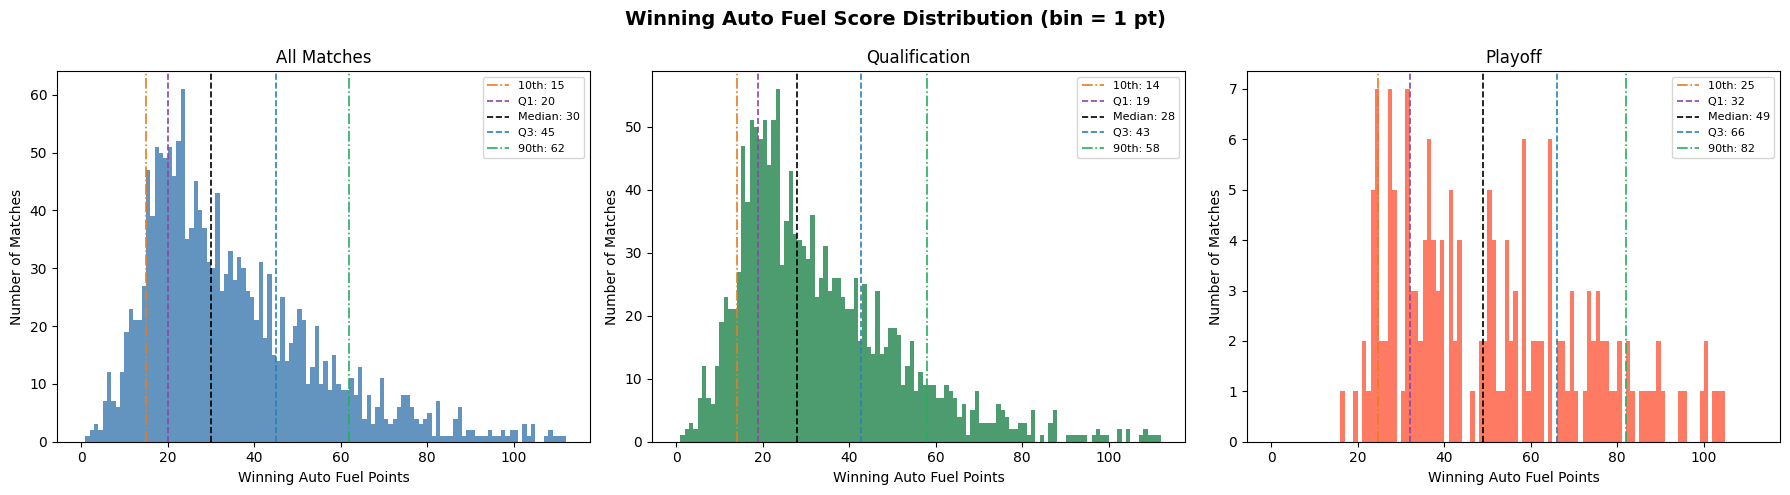

In [13]:
max_score = int(decisive["winning_auto_score"].max()) + 1
bins = np.arange(0, max_score + 1, 1)  # bin width of 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Winning Auto Fuel Score Distribution (bin = 1 pt)", fontsize=14, fontweight="bold")

subsets = [
    (decisive,                                      "All Matches",   "steelblue"),
    (decisive[decisive["match_type"] == "qual"],    "Qualification", "seagreen"),
    (decisive[decisive["match_type"] == "playoff"], "Playoff",       "tomato"),
]

ref_lines = [
    (10, "#e67e22", "-.", "10th"),
    (25, "#8e44ad", "--", "Q1"),
    (50, "black",   "--", "Median"),
    (75, "#2980b9", "--", "Q3"),
    (90, "#27ae60", "-.", "90th"),
]

for ax, (data, title, color) in zip(axes, subsets):
    ax.hist(data["winning_auto_score"], bins=bins, color=color, edgecolor="none", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Winning Auto Fuel Points")
    ax.set_ylabel("Number of Matches")
    for pct, lc, ls, lbl in ref_lines:
        val = np.percentile(data["winning_auto_score"], pct)
        ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 5 – Auto Fuel Win Margin Distribution (10% Percentiles)

The win margin is the difference in auto fuel points between the alliance that won auto fuel
and the alliance that lost. (Tower points are excluded.)

In [9]:
# Calculate auto fuel win margin (always positive: winner - loser)
decisive["auto_margin"] = (decisive[["red_auto_fuel_points", "blue_auto_fuel_points"]].max(axis=1)
                         - decisive[["red_auto_fuel_points", "blue_auto_fuel_points"]].min(axis=1))

# All matches
all_margin = percentile_table(decisive["auto_margin"], "All Matches")

# Quals only
quals_margin = percentile_table(
    decisive.loc[decisive["match_type"] == "qual", "auto_margin"], "Qualification"
)

# Playoffs only
playoffs_margin = percentile_table(
    decisive.loc[decisive["match_type"] == "playoff", "auto_margin"], "Playoff"
)

margin_df = all_margin.merge(quals_margin, on="Percentile").merge(playoffs_margin, on="Percentile")

print("Auto Fuel Win Margin Distribution (10% Percentiles)\n")
print(margin_df.to_string(index=False))

Auto Fuel Win Margin Distribution (10% Percentiles)

Percentile All Matches Qualification Playoff
        0%         1.0           1.0     1.0
       10%         3.0           3.0     4.0
       20%         5.0           5.0     7.0
       30%         8.0           8.0     9.4
       40%        11.0          10.0    14.0
       50%        14.0          14.0    18.0
       60%        18.0          17.0    22.8
       70%        23.0          22.0    27.0
       80%        30.0          29.0    39.4
       90%        40.6          39.0    51.0
      100%       103.0         103.0    73.0


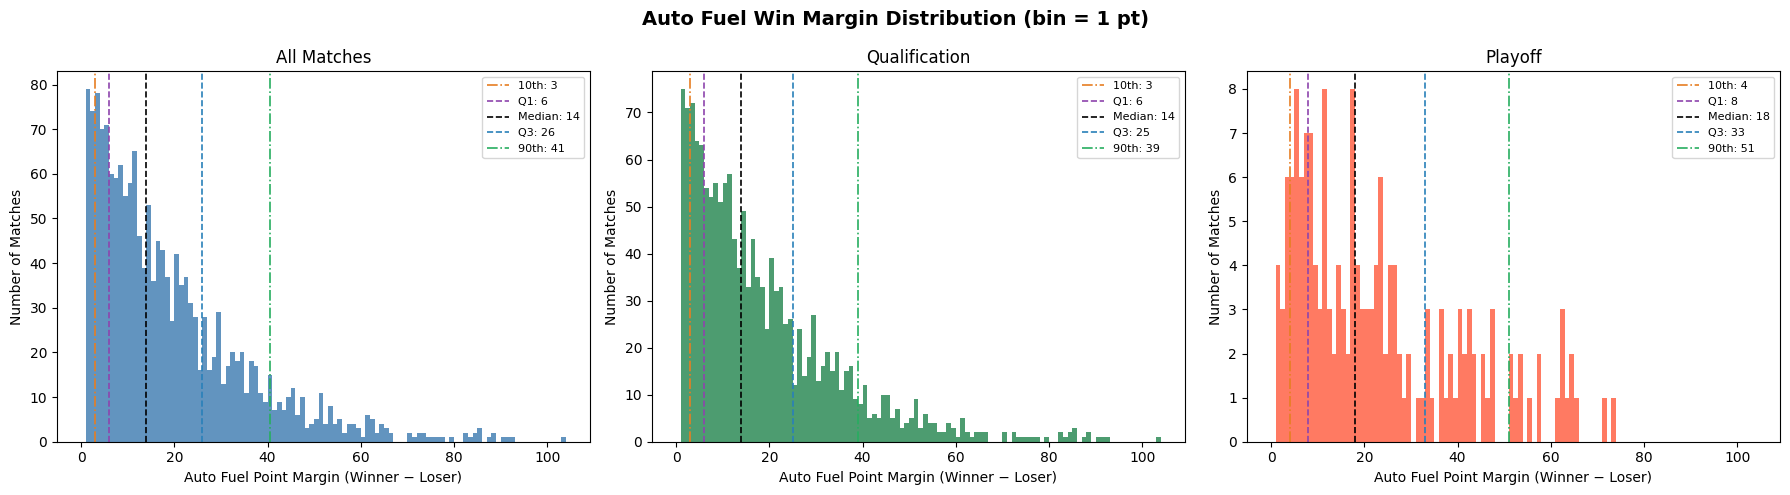

In [14]:
max_margin = int(decisive["auto_margin"].max()) + 1
bins_margin = np.arange(0, max_margin + 1, 1)  # bin width of 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Auto Fuel Win Margin Distribution (bin = 1 pt)", fontsize=14, fontweight="bold")

subsets = [
    (decisive,                                      "All Matches",   "steelblue"),
    (decisive[decisive["match_type"] == "qual"],    "Qualification", "seagreen"),
    (decisive[decisive["match_type"] == "playoff"], "Playoff",       "tomato"),
]

ref_lines = [
    (10, "#e67e22", "-.", "10th"),
    (25, "#8e44ad", "--", "Q1"),
    (50, "black",   "--", "Median"),
    (75, "#2980b9", "--", "Q3"),
    (90, "#27ae60", "-.", "90th"),
]

for ax, (data, title, color) in zip(axes, subsets):
    ax.hist(data["auto_margin"], bins=bins_margin, color=color, edgecolor="none", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Auto Fuel Point Margin (Winner − Loser)")
    ax.set_ylabel("Number of Matches")
    for pct, lc, ls, lbl in ref_lines:
        val = np.percentile(data["auto_margin"], pct)
        ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
def print_100th_percentile_matches(decisive_df, score_col, label):
    max_val = decisive_df[score_col].max()
    matches = decisive_df[decisive_df[score_col] == max_val][
        ["match_key", "event_key", "red_auto_fuel_points", "blue_auto_fuel_points", "winning_alliance"]
    ].copy()
    print(f"── 100th Percentile: {label} = {max_val:.0f} ─────────────────")
    for _, row in matches.iterrows():
        winning_auto_alliance = "Red" if row["red_auto_fuel_points"] > row["blue_auto_fuel_points"] else "Blue"
        print(f"  Match:    {row['match_key']}")
        print(f"  Event:    {row['event_key']}")
        print(f"  Alliance that scored {max_val:.0f}: {winning_auto_alliance}")
        print(f"  Red auto fuel pts: {row['red_auto_fuel_points']}   Blue auto fuel pts: {row['blue_auto_fuel_points']}")
        print(f"  Match winner: {row['winning_alliance'].capitalize()}")
        print()

# 100th percentile – winning auto fuel score
print_100th_percentile_matches(decisive, "winning_auto_score", "Winning Auto Fuel Score")

# 100th percentile – auto fuel win margin
print_100th_percentile_matches(decisive, "auto_margin", "Auto Fuel Win Margin")

── 100th Percentile: Winning Auto Fuel Score = 111 ─────────────────
  Match:    2026mefal_qm32
  Event:    2026mefal
  Alliance that scored 111: Blue
  Red auto fuel pts: 76   Blue auto fuel pts: 111
  Match winner: Blue

── 100th Percentile: Auto Fuel Win Margin = 103 ─────────────────
  Match:    2026mefal_qm9
  Event:    2026mefal
  Alliance that scored 103: Blue
  Red auto fuel pts: 4   Blue auto fuel pts: 107
  Match winner: Blue

